In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/Documents/optimal-control-notes-code/code/with-notes/exercise-2`
    Updating registry at `~/.julia/registries/General.toml`
    Updating `~/Documents/optimal-control-notes-code/code/with-notes/exercise-2/Project.toml`
  [f65535da] + Convex v0.15.3
  [e2685f51] + ECOS v1.1.1
  [f6369f11] + ForwardDiff v0.10.36
  [b8b539d8] + JupyterFormatter v0.1.0
  [b964fa9f] + LaTeXStrings v1.3.0
  [91a5bcdd] + Plots v1.38.17
  [d330b81b] + PyPlot v2.11.2
    Updating `~/Documents/optimal-control-notes-code/code/with-notes/exercise-2/Manifest.toml`
  [14f7f29c] + AMD v0.5.2
  [1520ce14] + AbstractTrees v0.4.4
  [6e4b80f9] + BenchmarkTools v1.3.2
  [d1d4a3ce] + BitFlags v0.1.7
  [fa961155] + CEnum v0.4.2
  [00ebfdb7] + CSTParser v3.3.6
⌅ [523fee87] + CodecBzip2 v0.7.2
  [944b1d66] + CodecZlib v0.7.2
  [35d6a980] + ColorSchemes v3.23.0
  [3da002f7] + ColorTypes v0.11.4
  [c3611d14] + ColorVectorSpace v0.10.0
  [5ae59095] + Colors v0.12.10
  [a80b9123] + CommonMark v0.8.12
  

In [2]:
using LaTeXStrings;
using Plots;
pyplot();
PyPlot.matplotlib.rc("text", usetex = true);
PyPlot.matplotlib.rc("font", family = "Times New Roman");
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}");

using JupyterFormatter;
enable_autoformat();

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


In [7]:
using LinearAlgebra
using Plots
import ForwardDiff as FD
import MeshCat as mc
using JLD2
using Test
using Random

[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c]
┌ Warning: Module Plots with build ID fafbfcfd-8ce0-e00a-0000-004a87276ab6 is missing from the cache.
│ This may mean Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c].


# Q2: LQR for nonlinear systems

## Linearization warmup 
Before we apply LQR to nonlinear systems, we are going to treat our linear system as if it's nonlinear. Specifically, we are going to "approximate" our linear system with a first-order Taylor series, and define a new set of $(\Delta x, \Delta u)$ coordinates. Since our dynamics are linear, this approximation is exact, allowing us to check that we set up the problem correctly. 

First, assume our discrete time dynamics are the following:

$$ x_{k+1} = f(x_k,u_k) $$

And we are going to linearize about a reference trajectory $\bar{x}_{1:N}, \bar{u}_{1:N-1}$. From here, we can define our delta's accordingly:

$$ \begin{align} x_k &= \bar{x}_k + \Delta x_k \\ u_k &= \bar{u}_k + \Delta u_k \end{align}$$  

Next, we are going to approximate our discrete time dynamics function with the following first order Taylor series:

$$ 
x_{k+1} \approx f(\bar{x}_k, \bar{u}_k) + \bigg[\frac{\partial f}{\partial x} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg](x_k - \bar{x}_k) + \bigg[\frac{\partial f}{\partial u} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg](u_k - \bar{u}_k)
$$

Which we can substitute in our delta notation to get the following:

$$ 
\bar{x}_{k+1} + \Delta x_{k+1} \approx f(\bar{x}_k, \bar{u}_k) + \bigg[\frac{\partial f}{\partial x} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg]\Delta x_k + \bigg[\frac{\partial f}{\partial u} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg] \Delta u_k
$$

If the trajectory $\bar{x},\bar{u}$ is dynamically feasible (meaning $\bar{x}_{k+1} = f(\bar{x}_k, \bar{u}_k)$), then we can cancel these equivalent terms on each side of the above equation, resulting in the following:

$$ 
 \Delta x_{k+1} \approx  \bigg[\frac{\partial f}{\partial x} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg]\Delta x_k + \bigg[\frac{\partial f}{\partial u} \bigg|_{\bar{x}_k, \bar{u}_k}  \bigg] \Delta u_k
$$

In [8]:
function dynamics(params::NamedTuple, x::Vector, u)

    # cartpole physical parameters 
    mc, mp, l = params.mc, params.mp, params.l
    g = 9.81

    q = x[1:2]
    qd = x[3:4]

    s = sin(q[2])
    c = cos(q[2])

    H = [mc+mp mp*l*c; mp*l*c mp*l^2]
    C = [0 -mp*qd[2]*l*s; 0 0]
    G = [0, mp * g * l * s]
    B = [1, 0]

    qdd = -H \ (C * qd + G - B * u[1])
    return [qd; qdd]
end;

In [9]:
function rk4(params::NamedTuple, x::Vector, u, dt::Float64)
    k1 = dt * dynamics(params, x, u)
    k2 = dt * dynamics(params, x + k1 / 2, u)
    k3 = dt * dynamics(params, x + k2 / 2, u)
    k4 = dt * dynamics(params, x + k3, u)
    return x + (1 / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
end;

In [15]:
function rotx(θ)
    s, c = sincos(θ)
    return [1 0 0; 0 c -s; 0 s c]
end
function create_cartpole!(vis)
    mc.setobject!(
        vis[:cart],
        mc.HyperRectangle(mc.Vec(-.25, -1.0, -.15), mc.Vec(0.5, 2, 0.3)),
    )
    mc.setobject!(vis[:pole], mc.Cylinder(mc.Point(0, 0, -.75), mc.Point(0, 0, 0.75), 0.05))
    mc.setobject!(vis[:a], mc.HyperSphere(mc.Point(0, 0, 0.0), 0.1))
    mc.setobject!(vis[:b], mc.HyperSphere(mc.Point(0, 0, 0.0), 0.1))
end
function update_cartpole_transform!(vis, x)
    pole_o = 0.3
    px = x[1]
    θ = x[2]
    mc.settransform!(vis[:cart], mc.Translation([0, px, 0.0]))
    p1 = [pole_o, px, 0]
    p2 = p1 + 1.5 * [0, sin(θ), -cos(θ)]
    mc.settransform!(vis[:a], mc.Translation(p1))
    mc.settransform!(vis[:b], mc.Translation(p2))
    mc.settransform!(vis[:pole], mc.Translation(0.5 * (p1 + p2)) ∘ mc.LinearMap(rotx(θ)))
end

function animate_cartpole(X, dt)
    vis = mc.Visualizer()
    create_cartpole!(vis)
    anim = mc.Animation(floor(Int, 1 / dt))
    for k = 1:length(X)
        mc.atframe(anim, k) do
            update_cartpole_transform!(vis, X[k])
        end
    end
    mc.setanimation!(vis, anim)
    return mc.render(vis)
end

animate_cartpole (generic function with 1 method)

dlqr converged after 74 iterations
norm(X[end] - xgoal) = 0.004605879135345364


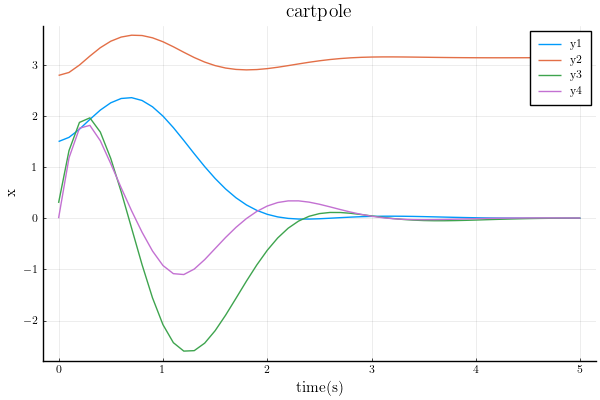

[ Info: Listening on: 127.0.0.1:8700, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8700


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), UInt8[0x83, 0xa7, 0x6f, 0x70, 0x74, 0x69, 0x6f, 0x6e, 0x73, 0x82  …  0x5f, 0x61, 0x6e, 0x69, 0x6d, 0x61, 0x74, 0x69, 0x6f, 0x6e], Dict{String, MeshCat.SceneTrees.SceneNode}("meshcat" => MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}("pole" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x70, 0x6f, 0x6c, 0x65], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "b" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x2f, 0x6d, 0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x62], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "cart" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x63, 0x61, 0x72, 0x74], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), "a" => MeshCat.SceneTrees.SceneNode(UInt8[0x83, 0xa6, 0x6f, 0x62, 0x6a, 0x65, 0x63, 0x74, 0x84, 0xaa  …  0x2f, 0x6d, 0x65, 0x73, 0x68, 0x63, 0x61, 0x74, 0x2f, 0x61], nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()))))), Set{HTTP.WebSockets.WebSocket}(), ip"127.0.0.1", 8700))

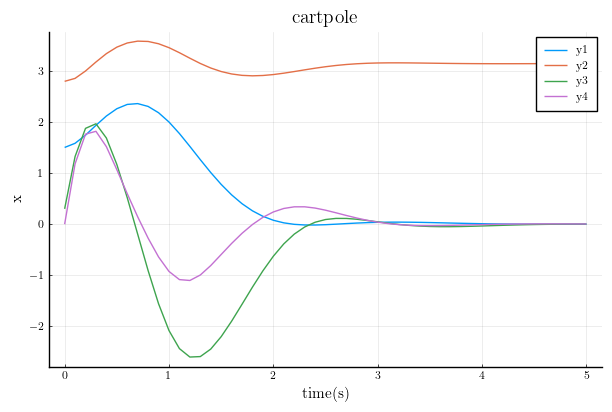

In [16]:
function ihlqr(
    A::Matrix,       # vector of A matrices 
    B::Matrix,       # vector of B matrices
    Q::Matrix,       # cost matrix Q 
    R::Matrix;       # cost matrix R 
    max_iter = 1000, # max iterations for Ricatti 
    tol = 1e-5,       # convergence tolerance
)::Tuple{Matrix,Matrix} # return two matrices 

    # get size of x and u from B 
    nx, nu = size(B)

    # initialize P with Q
    P = deepcopy(Q)

    # Ricatti 
    for ricatti_iter = 1:max_iter
        K = (R + B' * P * B) \ (B' * P * A)
        Pnew = Q + K' * R * K + (A - B * K)'P * (A - B * K)
        if norm(P - Pnew, Inf) < tol
            println("dlqr converged after $ricatti_iter iterations")
            return Pnew, K
        end

        # update P 
        P .= Pnew
    end
    error("dlqr did not converge")
end
let

    nx = 4
    nu = 1
    x0 = [0, pi, 0, 0] + [1.5, deg2rad(-20), 0.3, 0]
    xgoal = [0, pi, 0, 0]
    ugoal = [0]
    dt = 0.1
    tf = 5.0
    t_vec = 0:dt:tf
    N = length(t_vec)
    X = [zeros(nx) for i = 1:N]
    X[1] = x0


    params_est = (mc = 1.0, mp = 0.2, l = 0.5)
    params_real = (mc = 1.2, mp = 0.16, l = 0.55)

    A = FD.jacobian(_x -> rk4(params_est, _x, ugoal, dt), xgoal)
    B = FD.jacobian(_u -> rk4(params_est, xgoal, _u, dt), ugoal)
    Q = diagm([1, 1, 0.05, 0.1])
    Qf = 1 * Q
    R = 0.1 * diagm(ones(nu))
    Pinf, Kinf = ihlqr(A, B, Q, R)

    for i = 1:(N-1)
        u = -Kinf * (X[i] - xgoal)
        X[i+1] = rk4(params_real, X[i], u, dt)
    end


    @test X[1] == x0
    @show norm(X[end] - xgoal)
    Xm = hcat(X...)
    display(plot(
        t_vec,
        Xm',
        title = "cartpole",
        xlabel = "time(s)",
        ylabel = "x",
        # label = ["x", L"\theta", "\dot x", L"\dot \theta"]
    ))

    # animation stuff
    display(animate_cartpole(X, dt))

end